In [ ]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
data_uci = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = data_uci.data.features # type: ignore # tyoe: ignore
y = data_uci.data.targets  # type: ignore
  
# metadata 
print(data_uci.metadata) 
  
# variable information 
print(data_uci.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [66]:
y.squeeze

<bound method NDFrame.squeeze of        Y
0      1
1      1
2      0
3      0
4      0
...   ..
29995  0
29996  0
29997  1
29998  1
29999  1

[30000 rows x 1 columns]>

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

scaler = StandardScaler()

X = data_uci.data.features # type: ignore
y = data_uci.data.targets # type: ignore

# 1. Lista explícita de tus variables categóricas demográficas y demas
X_cat = ['X3', 'X2', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11']

X_num = [col for col in X.columns if col not in X_cat]

# 2. El preprocesador se encargará del resto automáticamente
preprocesamiento = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_num),  # Tus variables continuas (Edad, Ingresos, Saldos...)
        ('cat', OneHotEncoder(drop='first', sparse_output=False), X_cat) # <--- Aquí ocurre la magia de los 0 y 1
    ]
)


X_scaled = preprocesamiento.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y.squeeze(),
    test_size=0.2,
    stratify=y
)

model = LogisticRegression()

model.fit(X_train, y_train)

preds = model.predict(X_test)

In [68]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, preds)
cm

array([[4465,  208],
       [ 839,  488]])

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1 Score :", f1_score(y_test, preds))

Accuracy : 0.8255
Precision: 0.7011494252873564
Recall   : 0.3677467972871138
F1 Score : 0.4824518042511122


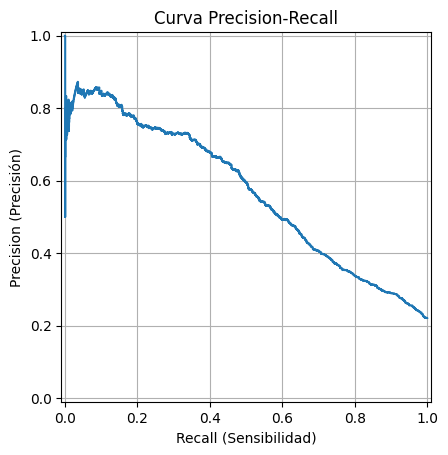

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

# 1. Obtener las probabilidades de la clase positiva (1)
# Usamos [:, 1] porque predict_proba devuelve [prob_clase_0, prob_clase_1]
y_scores = model.predict_proba(X_test)[:, 1]

# 2. Calcular los valores de precisión, recall y los umbrales
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Graficar la curva de forma automática
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

# Personalizar el gráfico
plt.title("Curva Precision-Recall")
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precision (Precisión)")
plt.grid(True)
plt.show()

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

# Definimos los modelos individuales (todos con probabilidad activa y balanceados)
clf1 = LogisticRegression(class_weight='balanced')
clf2 = RandomForestClassifier(
    n_estimators=150, 
    max_depth=8,              # <--- Ajuste clave: no lo dejes crecer tanto
    min_samples_leaf=5,       # <--- Exige al menos 5 datos por hoja para evitar que memorice casos aislados
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)
clf3 = HistGradientBoostingClassifier(
    max_depth=5,              # <--- Limita la complejidad de los árboles secuenciales
    l2_regularization=1.5,    # <--- Penaliza al modelo por volverse muy complejo
    class_weight='balanced', 
    random_state=42
)

# Creamos el ensamble por votación suave (soft usa las probabilidades predict_proba)
ensemble_voting = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('hgb', clf3)],
    voting='soft'
)

ensemble_voting.fit(X_train, y_train)

c:\Users\juane\.virtualenvs\ml_predict-sIOJZXET\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...ht='balanced'), RandomForestC...ndom_state=42), HistGradientB...ndom_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,82


In [72]:
import numpy as np
# Corre esto para ver cuál era el umbral perfecto del ensamble:
precision, recall, thresholds = precision_recall_curve(y_test, ensemble_voting.predict_proba(X_test)[:,1])
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
print("Umbral con el F1-Score más alto:", thresholds[np.argmax(f1_scores)])
print("F1 Máximo alcanzado:", np.max(f1_scores))

Umbral con el F1-Score más alto: 0.5171992995536633
F1 Máximo alcanzado: 0.5604781996689292


In [73]:
y_pred = (ensemble_voting.predict_proba(X_test)[:,1]>= thresholds[np.argmax(f1_scores)]).astype(int)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7916666666666666
Precision: 0.5253790375741595
Recall   : 0.60060286360211
F1 Score : 0.560478199718706


In [74]:
y_pred_train = (ensemble_voting.predict_proba(X_train)[:,1]>= thresholds[np.argmax(f1_scores)]).astype(int)
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall   :", recall_score(y_train, y_pred_train))
print("F1 Score :", f1_score(y_train, y_pred_train))

Accuracy : 0.791125
Precision: 0.5245358090185677
Recall   : 0.5959691090600866
F1 Score : 0.5579754871704435


In [86]:
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.metrics import make_scorer, f1_score, precision_recall_curve, accuracy_score, precision_score, recall_score

# ==============================================================================
# 1. DEFINICIÓN DE COLUMNAS Y PREPROCESADOR
# ==============================================================================
X_cat = ['X3', 'X2', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11']
X_num = [col for col in X.columns if col not in X_cat]

preprocesamiento = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_num),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), X_cat)
    ]
)

# ==============================================================================
# 2. DIVISIÓN ESTRATIFICADA  (ahora sobre X sin escalar)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,           # ← raw, sin escalar
    y,
    test_size=0.2,
    stratify=y
)

# ==============================================================================
# 3. ENSAMBLAJE DENTRO DE UN PIPELINE
# ==============================================================================
clf1 = LogisticRegression(class_weight='balanced')
clf2 = RandomForestClassifier(class_weight='balanced', n_jobs=-1)
clf3 = HistGradientBoostingClassifier(class_weight='balanced')

ensemble_voting = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('hgb', clf3)],
    voting='soft'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocesamiento),
    ('model', ensemble_voting)
])

# ==============================================================================
# 4. GRIDSEARCH  (los parámetros ahora llevan el prefijo 'model__')
# ==============================================================================
param_grid = {
    'model__rf__max_depth':        [6, 8, 10],
    'model__rf__min_samples_leaf': [3, 5, 10],
    'model__hgb__max_depth':       [3, 5, 7],
    'model__hgb__l2_regularization': [0.5, 1.5, 5.0]
}

cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True)
f1_scorer     = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=cv_estrategia,
    n_jobs=-1,
    verbose=1
)

print("Iniciando la optimización con K-Folds...")
grid_search.fit(X_train, y_train)

mejor_pipeline = grid_search.best_estimator_   # ← preprocessor + model juntos

print("\n--- ¡Optimización Completa! ---")
print("Mejores parámetros:", grid_search.best_params_)
print(f"Mejor F1 en K-Folds: {grid_search.best_score_:.4f}")

# ==============================================================================
# 5. UMBRAL ÓPTIMO  (igual que antes)
# ==============================================================================
probabilidades_train = mejor_pipeline.predict_proba(X_train)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, probabilidades_train)

f1_scores_curva = 2 * (precision * recall) / (precision + recall + 1e-10)
indice_optimo   = np.argmax(f1_scores_curva)
umbral_optimo   = thresholds[indice_optimo] if indice_optimo < len(thresholds) else thresholds[-1]

print(f"Umbral óptimo: {umbral_optimo:.4f}")

# ==============================================================================
# 6. EVALUACIÓN FINAL
# ==============================================================================
probabilidades_test = mejor_pipeline.predict_proba(X_test)[:, 1]
y_pred_final        = (probabilidades_test >= umbral_optimo).astype(int)

print("\n=============================================")
print("  MÉTRICAS FINALES EN TEST                  ")
print("=============================================")
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_final):.4f}")

# ==============================================================================
# 7. GUARDAR  (pipeline completo + umbral)
# ==============================================================================
joblib.dump(mejor_pipeline, "pipeline_produccion.pkl")
joblib.dump(umbral_optimo,  "umbral_optimo.pkl")
print("\nArtifacts guardados: pipeline_produccion.pkl, umbral_optimo.pkl")

Iniciando la optimización con K-Folds...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


c:\Users\juane\.virtualenvs\ml_predict-sIOJZXET\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\juane\.virtualenvs\ml_predict-sIOJZXET\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\juane\.virtualenvs\ml_predict-sIOJZXET\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch


--- ¡Optimización Completa! ---
Mejores parámetros: {'model__hgb__l2_regularization': 0.5, 'model__hgb__max_depth': 3, 'model__rf__max_depth': 6, 'model__rf__min_samples_leaf': 3}
Mejor F1 en K-Folds: nan
Umbral óptimo: 0.5538

  MÉTRICAS FINALES EN TEST                  
Accuracy : 0.7953
Precision: 0.5371
Recall   : 0.5396
F1 Score : 0.5383

Artifacts guardados: pipeline_produccion.pkl, umbral_optimo.pkl


In [78]:
X.sample(3)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
1276,480000,2,2,1,54,-2,-2,-2,-2,-2,...,1717,1385,0,0,6026,1717,1390,0,0,2300
23800,240000,2,1,1,55,-1,0,0,-2,-2,...,0,0,0,21585,3900,0,0,0,21585,0
4880,250000,2,1,2,43,0,0,0,0,0,...,90901,69927,71403,69948,4409,3023,2600,2700,2801,2500


In [79]:
X.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [80]:
import pandas as pd

X_cat = ['X3', 'X2', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11']

# 1. Seleccionamos solo las columnas categóricas de tu DataFrame original 'X'
# 2. Las transformamos todas juntas a tipo 'category'
x_categ = X[X_cat].astype('category')

# 3. Obtenemos el resumen estadístico descriptivo para variables categóricas
summary = x_categ.describe()

x_categ.describe()


,X3,X2,X4,X6,X7,X8,X9,X10,X11
count,30000,30000,30000,30000,30000,30000,30000,30000,30000
unique,7,2,4,11,11,11,11,10,10
top,2,2,2,0,0,0,0,0,0
freq,14030,18112,15964,14737,15730,15764,16455,16947,16286


In [81]:
import pandas as pd

X_cat = ['X3', 'X2', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11']

# 1. Creamos el DataFrame con el tipo de dato correcto
x_categ = X[X_cat].astype('category')

print("==================================================")
print("  RESUMEN GENERAL DE TODAS LAS CATEGÓRICAS       ")
print("==================================================")
# .T transpone la tabla (la gira) para que sea mucho más fácil de leer si son muchas columnas
print(x_categ.describe().T)
print("\n")

print("==================================================")
print("  CONTEO DETALLADO DE VALORES POR COLUMNA        ")
print("==================================================")

# 2. Recorremos cada columna para ver cuántos datos hay de cada categoría (-1, 0, 1, 2...)
for col in X_cat:
    print(f"\n--- Distribución de la variable: {col} ---")
    print(x_categ[col].value_counts())

  RESUMEN GENERAL DE TODAS LAS CATEGÓRICAS       
     count  unique  top   freq
X3   30000       7    2  14030
X2   30000       2    2  18112
X4   30000       4    2  15964
X6   30000      11    0  14737
X7   30000      11    0  15730
X8   30000      11    0  15764
X9   30000      11    0  16455
X10  30000      10    0  16947
X11  30000      10    0  16286


  CONTEO DETALLADO DE VALORES POR COLUMNA        

--- Distribución de la variable: X3 ---
X3
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

--- Distribución de la variable: X2 ---
X2
2    18112
1    11888
Name: count, dtype: int64

--- Distribución de la variable: X4 ---
X4
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

--- Distribución de la variable: X6 ---
X6
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64

--- Distribución de la variable:

In [82]:
X[X_num].describe().to_csv('summary.csv')

In [83]:
import numpy as np
import pandas as pd
from scipy.stats import truncnorm
 
# ── Config ─────────────────────────────────────────────────────────────────
N = 6000
SEED = 42
rng = np.random.default_rng(SEED)
 
 
# ── Helpers ────────────────────────────────────────────────────────────────
def sample_categorical(values, probs, n):
    """Sample n values from a discrete distribution."""
    return rng.choice(values, size=n, p=probs)
 
 
def sample_truncated_normal(mean, std, low, high, n):
    """Sample from a normal distribution clipped to [low, high]."""
    a, b = (low - mean) / std, (high - mean) / std
    return truncnorm.rvs(a, b, loc=mean, scale=std, size=n, random_state=SEED)
 
 
# ── Categorical columns ────────────────────────────────────────────────────
cat_specs = {
    "X2":  {"values": [2, 1],
             "probs":  [18112, 11888]},
    "X3":  {"values": [2, 1, 3, 5, 4, 6, 0],
             "probs":  [14030, 10585, 4917, 280, 123, 51, 14]},
    "X4":  {"values": [2, 1, 3, 0],
             "probs":  [15964, 13659, 323, 54]},
    "X6":  {"values": [0, -1,  1, -2,  2,  3,  4,  5,  8,  6,  7],
             "probs":  [14737, 5686, 3688, 2759, 2667, 322, 76, 26, 19, 11, 9]},
    "X7":  {"values": [0, -1,  2, -2,  3,  4,  1,  5,  7,  6,  8],
             "probs":  [15730, 6050, 3927, 3782, 326, 99, 28, 25, 20, 12, 1]},
    "X8":  {"values": [0, -1, -2,  2,  3,  4,  7,  6,  5,  1,  8],
             "probs":  [15764, 5938, 4085, 3819, 240, 76, 27, 23, 21, 4, 3]},
    "X9":  {"values": [0, -1, -2,  2,  3,  4,  7,  5,  6,  1,  8],
             "probs":  [16455, 5687, 4348, 3159, 180, 69, 58, 35, 5, 2, 2]},
    "X10": {"values": [0, -1, -2,  2,  3,  4,  7,  5,  6,  8],
             "probs":  [16947, 5539, 4546, 2626, 178, 84, 58, 17, 4, 1]},
    "X11": {"values": [0, -1, -2,  2,  3,  4,  7,  6,  5,  8],
             "probs":  [16286, 5740, 4895, 2766, 184, 49, 46, 19, 13, 2]},
}
 
# ── Continuous columns ─────────────────────────────────────────────────────
# Using truncated normal for all: respects observed min/max boundaries.
# X18-X23: payment amounts floored at 0 (no negatives).
cont_specs = {
    "X1":  {"mean": 167484.32, "std": 129747.66, "min": 10000,    "max": 1000000},
    "X5":  {"mean": 35.49,     "std": 9.22,      "min": 21,       "max": 79},
    "X12": {"mean": 51223.33,  "std": 73635.86,  "min": -165580,  "max": 964511},
    "X13": {"mean": 49179.08,  "std": 71173.77,  "min": -69777,   "max": 983931},
    "X14": {"mean": 47013.15,  "std": 69349.39,  "min": -157264,  "max": 1664089},
    "X15": {"mean": 43262.95,  "std": 64332.86,  "min": -170000,  "max": 891586},
    "X16": {"mean": 40311.40,  "std": 60797.16,  "min": -81334,   "max": 927171},
    "X17": {"mean": 38871.76,  "std": 59554.11,  "min": -339603,  "max": 961664},
    "X18": {"mean": 5663.58,   "std": 16563.28,  "min": 0,        "max": 873552},
    "X19": {"mean": 5921.16,   "std": 23040.87,  "min": 0,        "max": 1684259},
    "X20": {"mean": 5225.68,   "std": 17606.96,  "min": 0,        "max": 896040},
    "X21": {"mean": 4826.08,   "std": 15666.16,  "min": 0,        "max": 621000},
    "X22": {"mean": 4799.39,   "std": 15278.31,  "min": 0,        "max": 426529},
    "X23": {"mean": 5215.50,   "std": 17777.47,  "min": 0,        "max": 528666},
}
 
# ── Generate ───────────────────────────────────────────────────────────────
data = {}
 
for col, spec in cat_specs.items():
    counts = np.array(spec["probs"], dtype=float)
    probs  = counts / counts.sum()
    data[col] = sample_categorical(spec["values"], probs, N)
 
for col, spec in cont_specs.items():
    data[col] = sample_truncated_normal(
        spec["mean"], spec["std"], spec["min"], spec["max"], N
    )
 
# ── Assemble and sort columns X1 → X23 ────────────────────────────────────
df = pd.DataFrame(data)
col_order = [f"X{i}" for i in range(1, 24)]
df = df[col_order]
 
# Round integer-natured columns
int_cols = ["X1", "X5"] + [f"X{i}" for i in range(12, 24)]
df[int_cols] = df[int_cols].round(0).astype(int)


In [84]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,...,6000.000000,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.00000,6000.00000,6000.000000,6000.000000
mean,194368.098667,1.612667,1.843333,1.546333,36.542500,-0.026667,-0.119000,-0.165333,-0.234167,-0.253833,...,46730.410500,42773.191667,43100.574167,38312.01850,15399.761167,20577.608667,16023.16500,14333.19850,14018.668333,16152.171167
std,108079.953105,0.487181,0.797848,0.524626,8.220693,1.129676,1.196555,1.172559,1.198988,1.122770,...,68849.605425,64180.459182,57336.991863,59609.26885,11036.342460,14976.793941,11578.82634,10336.37713,10098.309507,11679.300083
min,10007.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-157110.000000,-169549.000000,-81321.000000,-213099.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,110593.000000,1.000000,1.000000,1.000000,30.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-432.000000,-927.500000,1731.250000,-2101.25000,6574.750000,8605.750000,6765.50000,6068.75000,5944.750000,6814.500000
50%,185328.500000,2.000000,2.000000,2.000000,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,46857.000000,43025.000000,41787.500000,38617.00000,13504.000000,17889.500000,13986.00000,12525.00000,12258.000000,14094.000000
75%,265862.500000,2.000000,2.000000,2.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93322.500000,86163.250000,81930.250000,78564.25000,22130.250000,29616.250000,23045.50000,20611.25000,20156.250000,23232.500000
max,619023.000000,2.000000,6.000000,3.000000,67.000000,8.000000,7.000000,7.000000,7.000000,8.000000,...,286163.000000,265094.000000,250320.000000,244217.00000,64784.000000,88478.000000,68197.00000,60828.00000,59400.000000,68807.000000


In [87]:
import joblib
pipeline      = joblib.load("pipeline_produccion.pkl")
umbral_optimo = joblib.load("umbral_optimo.pkl")

probabilidades = pipeline.predict_proba(df)[:, 1]
predicciones   = (probabilidades >= umbral_optimo).astype(int)

df["prob_default"]  = probabilidades
df["pred_default"]  = predicciones

In [90]:
df['pred_default'].value_counts()

pred_default
0    5431
1     569
Name: count, dtype: int64